In [1]:
import sys
import torch
import functools
import matplotlib.pyplot as plt
import argparse, yaml, os
import torch.optim.lr_scheduler as lr_scheduler
import torchvision.transforms as transforms
import seaborn as sns
import pandas as pd
import tqdm
import glob

import tempfile, os
import numpy as np
from scipy.io import wavfile
from scipy import signal

from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from types import SimpleNamespace

from IPython.display import clear_output

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params as model_params_tm
from texture_prior.params import statistics_set, texture_dataset
from texture_prior.utils import path, normalization

sys.path.append('../utls/')
sys.path.append('../src/model/')
sys.path.append("/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/")
import DistanceMemoryModel
import encoders

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir


sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")
device = 'cuda'
# get soem textures
pc_dims = 256

pc_texture_model = encoders.AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.01,
    duration=2.0,
    device=device
)

def compute_likelihood(score_model, input_stats, ckpt):
    """Computing the actual "prior" value
    If the score function can be treated as the vector field govering the temporal evolution
    of $x_t$ then we can integrate the ODE and apply a change of basis to evaluate the prior
    """
    score_model.load_state_dict(torch.load(ckpt))
    input_stats = input_stats.to(device)

    _, bpd = ode_likelihood(input_stats, score_model, marginal_prob_std_fn,
                            diffusion_coeff_fn,
                            input_stats.shape[0], device=device, eps=1e-5)
    
    return bpd

def parse(d):
  x = SimpleNamespace()
  _ = [setattr(x, k, parse(v)) if isinstance(v, dict) else setattr(x, k, v) for k, v in d.items() ]    
  return x

In [2]:
normalization_dict = torch.load(path.relative('../assets/normalization_dict.pt'))
#normalization.get_normalization_function(normalization_dict, device)


In [3]:
def get_dataset(batch_size, num_workers, 
                stationarity_screen_list='/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/stimuli/OVERLAPPED_0.5s_all_4s_sound_list_with_stationarity_score_no_speech_no_music_audioset_matlab_coch_rms0p02.csv', 
                audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/', 
                duration=4):
    dataset = texture_dataset.AudioSetTextures(stationarity_screen_list, audioset_path, duration)
    #return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return dataset

dataloader = get_dataset(16, 4)
audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/'

In [4]:
dataloader.texture_list
unique_sounds = list(set(dataloader.texture_list.filepath.tolist()))
unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds] ## TODO: CREATE NEW SOUNDS WAV FILES THAT ARE CROPPED 
## 2S SOUNDS THAT START AT THE ONSET SEPCIFIED
## THEY SHOULD BE TEMPORARY

In [5]:
# --- Settings ---
max_ranking = 2        # only keep within_sound_ranking < this
#sr_target = 41000        # pc_texture_model expects 20kHz
segment_dur = 2.0        # seconds
#segment_samples = int(sr_target * segment_dur)

# --- Filter the texture list ---
tex_df = dataloader.texture_list
tex_df_filt = tex_df[tex_df['within_sound_ranking'] <= max_ranking].copy()
#unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds]
print(f"Filtered: {len(tex_df_filt)} / {len(tex_df)} segments (within_sound_ranking < {max_ranking})")

# --- Create temp dir and extract 2s segments ---
tmp_dir = tempfile.mkdtemp(prefix="prior_2s_segments_")
tmp_paths = []
skipped = 0

for idx, row in tqdm.tqdm(tex_df_filt.iterrows(), total=len(tex_df_filt)):
    src_path = '/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/' + row['filepath']
    onset = float(row['onset_time'])

    try:
        sr_orig, audio = wavfile.read(src_path)
    except Exception as e:
        print(e)
        skipped += 1
        continue

    audio = audio.astype(np.float64)

    # Extract 2s segment at original sample rate, then resample
    start_sample = int(onset * sr_orig)
    end_sample = start_sample + int(segment_dur * sr_orig)

    if end_sample > len(audio):
        skipped += 1
        continue

    segment = audio[start_sample:end_sample]

    # Save temp wav
    out_name = f"seg_{idx:06d}.wav"
    out_path = os.path.join(tmp_dir, out_name)
    wavfile.write(out_path, sr_orig, segment.astype(np.float64))
    tmp_paths.append(out_path)

    if idx > 100000:
        break

print(f"Created {len(tmp_paths)} temp files in {tmp_dir} (skipped {skipped})")

Filtered: 116388 / 426893 segments (within_sound_ranking < 2)


  4%|▎         | 4344/116388 [00:31<13:30, 138.28it/s]

Created 4345 temp files in /tmp/prior_2s_segments_81qq7yqg (skipped 0)


In [6]:
# parser.add_argument('--config', type=str, required=True, help='model + data configuration')
# parser.add_argument('--train', action='store_true', help='train the score-based model')
# parser.add_argument('--sample', action='store_true', help='sample from a trained model')
# parser.add_argument('--likelihood_eval', action='store_true', help='evaluate the data likelihood')
# parser.add_argument('--restart', action='store_true')
# parser.add_argument('--mode', type=str, default='textures', choices=['textures', 'mixtures'])

# sys.path.append('/orcd/data/jhm/001/om2/lakshmin/audio-prior/')
# from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
# from utils import synthesis, projection, audio
# from utils.sde_utils import *

import sys
import importlib.util
import os

# Add the new path
audio_prior_path = '/orcd/data/jhm/001/om2/lakshmin/audio-prior/'
sys.path.insert(0, audio_prior_path)  # insert at front of sys.path

from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
from utils import synthesis, projection, audio
from utils.sde_utils import *

config = "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/assets/bryan.yaml"
train = False
sample = False
likelihood_eval = True
restart = False
mode = 'textures'

device = 'cuda'

In [7]:
df = yaml.safe_load(open(config))
cfg = parse(df)

print(cfg)
num_sounds = 5000


pt_file = torch.load('/orcd/data/jhm/001/om2/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt')
pt_file = pt_file[:num_sounds, :]

namespace(train=namespace(n_epochs=512, batch_size=4096, lr=0.0001), data=namespace(data_root='/orcd/data/jhm/001/om2/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt', data_mix_root='/orcd/data/jhm/001/om2/lakshmin/audio-prior/assets/mixture_statistics_4096PCs.pt', n_pcs=256, var_scale=False), model=namespace(ckpt_path='ckpts/texture_diffusion2D_prior_{}pcs_mode_{}.pth', use_single_dim_conv=False, embed_dim=256, channels=[32, 64, 128], kernel_size=5, dilations=[1, 2, 4, 8, 16]), sample=namespace(sample_batch_size=4096, num_steps=2500))


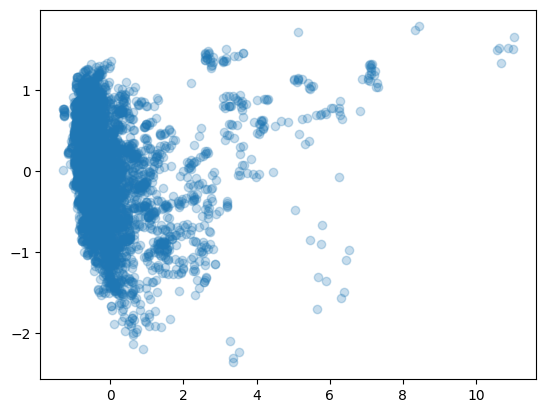

In [8]:
plt.scatter(pt_file[:num_sounds,0], pt_file[:num_sounds,1], alpha=0.25)

In [9]:
score_model = torch.nn.DataParallel(
                    ScoreNetAudioV2(
                        marginal_prob_std=marginal_prob_std_fn, 
                        channels=cfg.model.channels, 
                        embed_dim=cfg.model.embed_dim
                        )
                    )

score_model = score_model.to(device)

ckpt_path = cfg.model.ckpt_path.format(cfg.data.n_pcs, mode)
ckpt_path = "/orcd/data/jhm/001/om2/lakshmin/audio-prior/" + ckpt_path
if 'SLURM_RESTART_COUNT' in os.environ.keys() or restart:
    score_model.load_state_dict(torch.load(ckpt_path))

print(ckpt_path)

/orcd/data/jhm/001/om2/lakshmin/audio-prior/ckpts/texture_diffusion2D_prior_256pcs_mode_textures.pth


In [10]:
from dataloader import TextureStatsDataset
texture_dataset = TextureStatsDataset(
                config=cfg,                        
                device=device
            )

print(texture_dataset)

sounds_to_test = 1000
effective_num_sounds = sounds_to_test

rep = []

t_something = 0.01

exp_sounds = unique_sounds


for sound in glob.glob(tmp_dir+"/*")[:sounds_to_test]:
    vec = pc_texture_model(sound)

    try:
        if not torch.is_tensor(vec):
            vec = torch.tensor(vec)  # convert if it's a numpy array
        rep.append(vec)

        t = torch.tensor([t_something], device=vec.device).float()

        

        score = score_model(vec.view(1, 1, 1, 256), t)

        # 2. Flatten for norm computation per sample
        score_flat = score.view(score.size(0), -1)  # [B, 256]
        
        # 3. Normalize: divide by norm per sample
        norms = score_flat.norm(p=2, dim=1, keepdim=True) + 1e-8  # prevent division by zero
        unit_score_flat = score_flat / norms  # [B, 256]

        #print(unit_score_flat)
        
        # 4. Reshape back to original format
        unit_score = unit_score_flat.view_as(score)  # [B, 1, 1, 256]

        #input()
        #clear_output(wait=True)

    
    except Exception as e:
        effective_num_sounds -= 1


# Now stack all into one tensor
x = torch.stack(rep).float()  # shape: [N, ...]
x = x.view(len(rep), 1, 1, 256)

bpd_textures = compute_likelihood(score_model, input_stats=x, ckpt=ckpt_path)

x_numpy = x.squeeze(1).squeeze(1).detach().cpu().numpy()


In [11]:
x_orig = x_numpy
idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)
x_orig = x_orig[idx]

/tmp/ipykernel_1659191/2645570267.py:2: DeprecationWarning: This function is deprecated. Please call randint(0, 999 + 1) instead
  idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)


In [12]:
sample_batch_size = cfg.sample.sample_batch_size
sampler = Euler_Maruyama_sampler_1d if cfg.model.use_single_dim_conv else Euler_Maruyama_sampler
init_dims = [1, cfg.data.n_pcs] if cfg.model.use_single_dim_conv else [1, 1, cfg.data.n_pcs]


# generate samples using the specified sampler.
samples, trajectory = sampler(
                        score_model,
                        marginal_prob_std_fn,
                        diffusion_coeff_fn,
                        num_steps=cfg.sample.num_steps,
                        batch_size=sample_batch_size//2,
                        device=device,
                        init_dims=init_dims)

samples = samples.squeeze().detach().cpu().numpy()

100%|██████████| 2500/2500 [00:43<00:00, 57.64it/s]


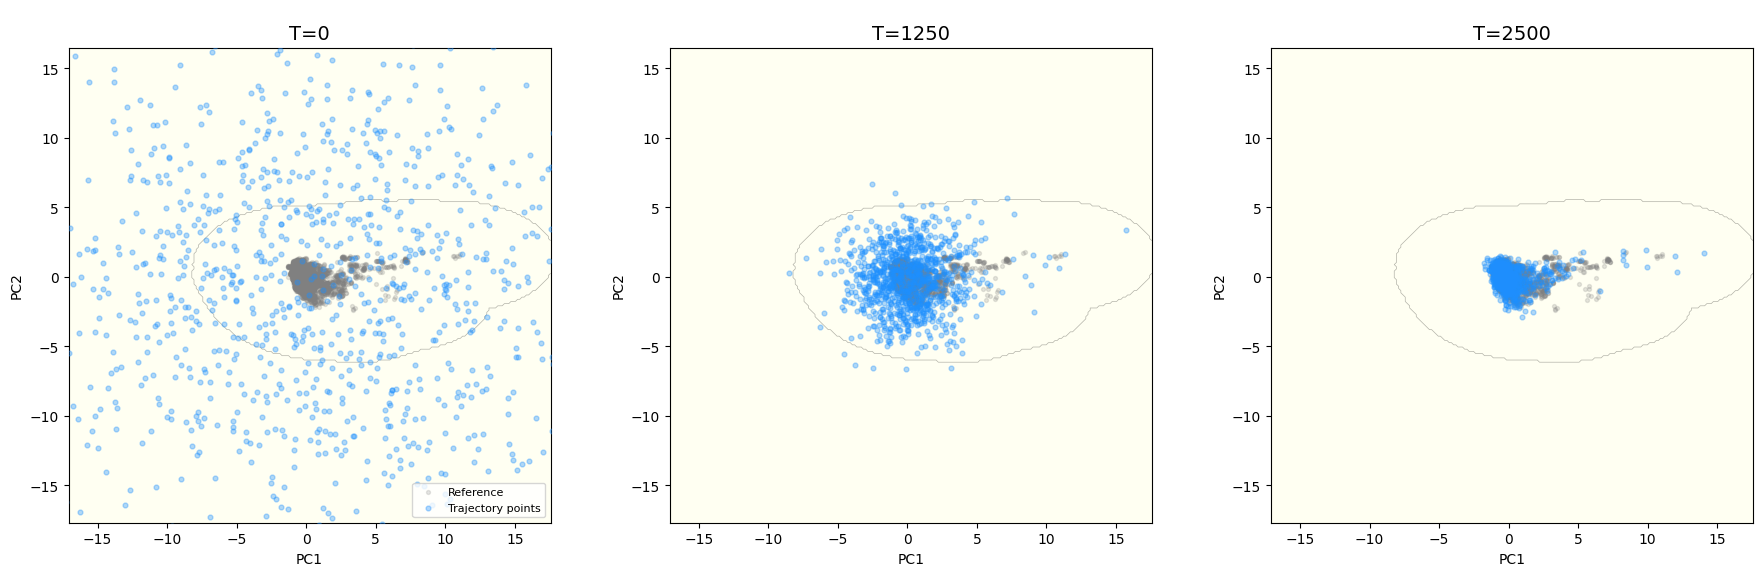

T=2501, N=2048, D=256, showing 1000 trajectories at t=[0, 1250, 2500]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# traj_np already has shape (T, N, D) = (2501, 4096, 256)
# If rebuilding:
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])  # (T, N, D)

traj_np.shape

T, N, D = traj_np.shape
traj_2d = traj_np[:, :, :2]   # (T, N, 2)
Z_train = pt_file[:5000, :2]

# pick timesteps from T axis
t_check = [0, T // 2, T - 1]

# subset trajectories from N axis
rng = np.random.default_rng(
)
n_show = min(1000, N)
n_idx = rng.choice(N, size=n_show, replace=False)

# bounds from train + shown trajectory points at selected timesteps
sel_pts = traj_2d[t_check][:, n_idx, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background on train data
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(t_check), figsize=(18, 5.5), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t in zip(axes, t_check):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[t, n_idx, 0], traj_2d[t, n_idx, 1],
               c="dodgerblue", s=12, alpha=0.35, label="Trajectory points", zorder=4)

    ax.set_title(f"T={t}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(" ", fontsize=18, y=1.02)
plt.show()

print(f"T={T}, N={N}, D={D}, showing {n_show} trajectories at t={t_check}")


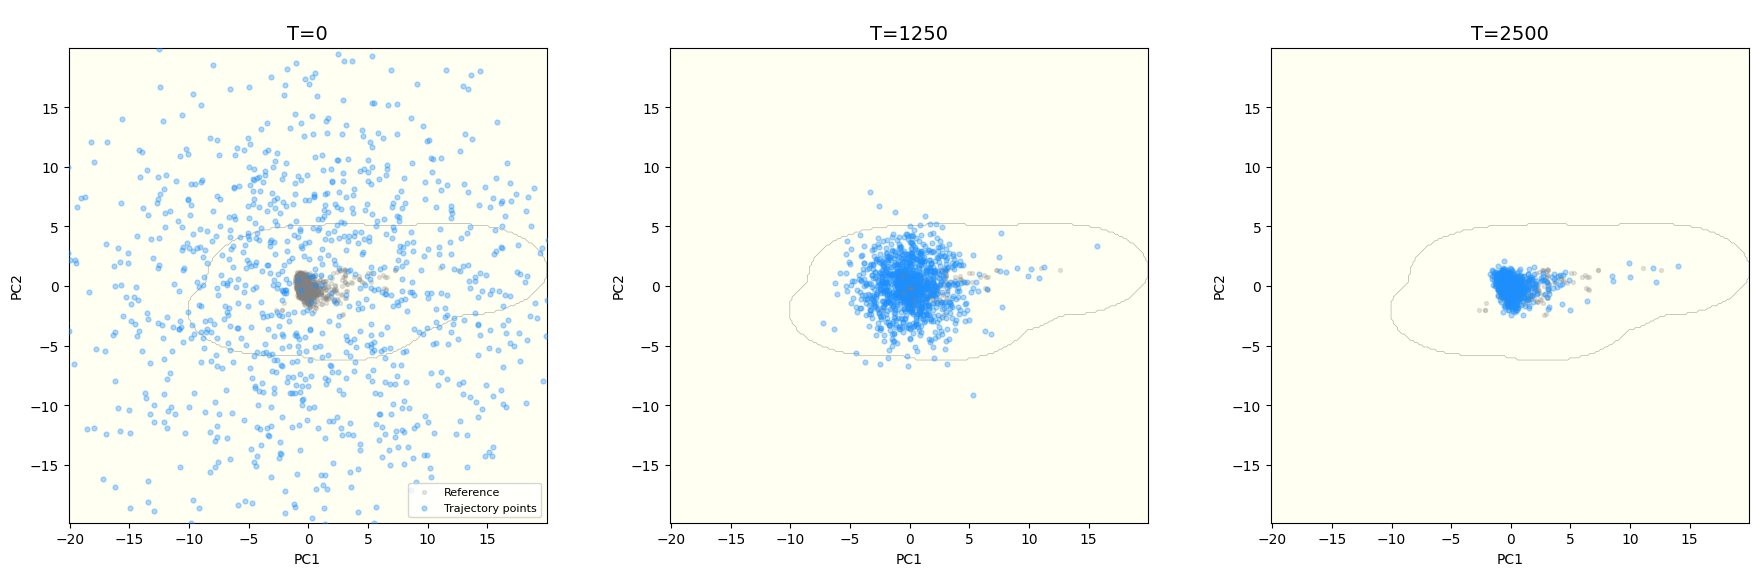

T=2501, N=2048, D=256, showing 1000 trajectories at t=[0, 1250, 2500]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# traj_np already has shape (T, N, D) = (2501, 4096, 256)
# If rebuilding:
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])  # (T, N, D)

traj_np.shape

T, N, D = traj_np.shape
traj_2d = traj_np[:, :, :2]   # (T, N, 2)
Z_train = x_numpy[:, :2]

# pick timesteps from T axis
t_check = [0, T // 2, T - 1]

# subset trajectories from N axis
rng = np.random.default_rng(
)
n_show = min(1000, N)
n_idx = rng.choice(N, size=n_show, replace=False)

# bounds from train + shown trajectory points at selected timesteps
sel_pts = traj_2d[t_check][:, n_idx, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background on train data
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(t_check), figsize=(18, 5.5), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t in zip(axes, t_check):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[t, n_idx, 0], traj_2d[t, n_idx, 1],
               c="dodgerblue", s=12, alpha=0.35, label="Trajectory points", zorder=4)

    ax.set_title(f"T={t}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(" ", fontsize=18, y=1.02)
plt.show()

print(f"T={T}, N={N}, D={D}, showing {n_show} trajectories at t={t_check}")


In [ ]:
# Marginalized 2D likelihood surface + arrows from its gradient
# Goal: plot log p(PC1, PC2) where remaining dimensions are marginalized out.
# We approximate: log p(x,y) = log \int p(x,y,z) dz
# using importance sampling / Monte Carlo over z (the other 254 PCs).

import numpy as np
import torch
import matplotlib.pyplot as plt

assert 'x_numpy' in globals(), "Need x_numpy in memory."
assert 'score_model' in globals(), "Need score_model in memory."
assert 'compute_likelihood' in globals(), "Need compute_likelihood helper in memory."
assert 'ckpt_path' in globals(), "Need ckpt_path in memory."

# -----------------------------
# Config
# -----------------------------
pc_i, pc_j = 0, 1
bounds_q = (0.5, 99.5)
Nx, Ny = 45, 45                 # grid in (PC1, PC2)
K = 256                         # number of z samples for MC marginalization
batch_size_ll = 2048            # batch size for compute_likelihood calls

# Proposal for z = all dims except (pc_i, pc_j)
proposal = 'gaussian'           # {'gaussian', 'empirical'}
seed = 0

# -----------------------------
# Setup
# -----------------------------
rng = np.random.default_rng(seed)
X = np.asarray(x_numpy, dtype=np.float32)
N, D = X.shape
assert D >= 3, "Need at least 3 dimensions to marginalize."

other_idx = np.array([d for d in range(D) if d not in (pc_i, pc_j)])
X_other = X[:, other_idx]  # (N, D-2)

x_lo, x_hi = np.percentile(X[:, pc_i], bounds_q)
y_lo, y_hi = np.percentile(X[:, pc_j], bounds_q)

xs = np.linspace(x_lo, x_hi, Nx, dtype=np.float32)
ys = np.linspace(y_lo, y_hi, Ny, dtype=np.float32)
GX, GY = np.meshgrid(xs, ys)

# Precompute proposal terms q(z)
if proposal == 'gaussian':
    mu = X_other.mean(axis=0)
    std = X_other.std(axis=0) + 1e-6

    def sample_z(k):
        z = rng.normal(loc=mu, scale=std, size=(k, D-2)).astype(np.float32)
        # log q(z) for diagonal Gaussian
        logq = -0.5 * np.sum(((z - mu) / std) ** 2 + 2*np.log(std) + np.log(2*np.pi), axis=1)
        return z, logq.astype(np.float32)

elif proposal == 'empirical':
    def sample_z(k):
        idx = rng.choice(X_other.shape[0], size=k, replace=True)
        z = X_other[idx].astype(np.float32)
        # for empirical proposal, treat q as constant over support (self-normalized approx)
        logq = np.zeros((k,), dtype=np.float32)
        return z, logq
else:
    raise ValueError(f"Unknown proposal={proposal}")


def eval_logp_full(points_full, bs=1024):
    """Return log p(full point) from BPD output: log p = -BPD * D * ln(2)."""
    out = np.empty((points_full.shape[0],), dtype=np.float32)
    for s in range(0, points_full.shape[0], bs):
        e = min(points_full.shape[0], s + bs)
        xb = torch.as_tensor(points_full[s:e], dtype=torch.float32).view(-1, 1, 1, D)
        bpd = compute_likelihood(score_model, input_stats=xb, ckpt=ckpt_path)
        if torch.is_tensor(bpd):
            bpd = bpd.detach().cpu().numpy().reshape(-1)
        else:
            bpd = np.asarray(bpd).reshape(-1)
        # convert bits/dim -> log-likelihood (natural log)
        out[s:e] = (-bpd * D * np.log(2.0)).astype(np.float32)
    return out


# -----------------------------
# Monte Carlo marginalization
# -----------------------------
logp_marg = np.empty((Ny, Nx), dtype=np.float32)

for iy, yv in enumerate(ys):
    for ix, xv in enumerate(xs):
        z_samp, logq = sample_z(K)                     # (K, D-2), (K,)

        full = np.zeros((K, D), dtype=np.float32)
        full[:, pc_i] = xv
        full[:, pc_j] = yv
        full[:, other_idx] = z_samp

        logp_full = eval_logp_full(full, bs=batch_size_ll)  # (K,)

        # log p(x,y) ~= log mean_k exp(log p(x,y,z_k) - log q(z_k))
        w = logp_full - logq
        m = np.max(w)
        logp_xy = m + np.log(np.mean(np.exp(w - m)) + 1e-30)
        logp_marg[iy, ix] = logp_xy


# -----------------------------
# Arrows from gradient of marginalized log-likelihood
# -----------------------------
# np.gradient returns [d/dy, d/dx] for matrix indexed as [y, x]
dlogp_dy, dlogp_dx = np.gradient(logp_marg, ys, xs)
U = dlogp_dx
V = dlogp_dy

# normalize arrows to show direction field cleanly
norm = np.sqrt(U**2 + V**2) + 1e-8
Uu, Vu = U / norm, V / norm

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8.4, 7.2))
plt.contourf(GX, GY, logp_marg, levels=40, cmap='viridis', alpha=0.92)
plt.contour(GX, GY, logp_marg, levels=12, colors='k', linewidths=0.35, alpha=0.35)

plt.quiver(
    GX, GY, Uu, Vu,
    color='white', alpha=0.95,
    angles='xy', scale_units='xy', scale=28,
    width=0.0025, headwidth=3.5, headlength=4.8,
)

plt.xlabel(f'PC{pc_i+1}')
plt.ylabel(f'PC{pc_j+1}')
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)
plt.title(
    f'Marginalized log-likelihood log p(PC{pc_i+1},PC{pc_j+1}) + gradient arrows\n'
    f'grid={Nx}x{Ny}, MC samples K={K}, proposal={proposal}'
)
cbar = plt.colorbar()
cbar.set_label('log p(x, y) (MC-marginalized)')
plt.tight_layout()
plt.show()

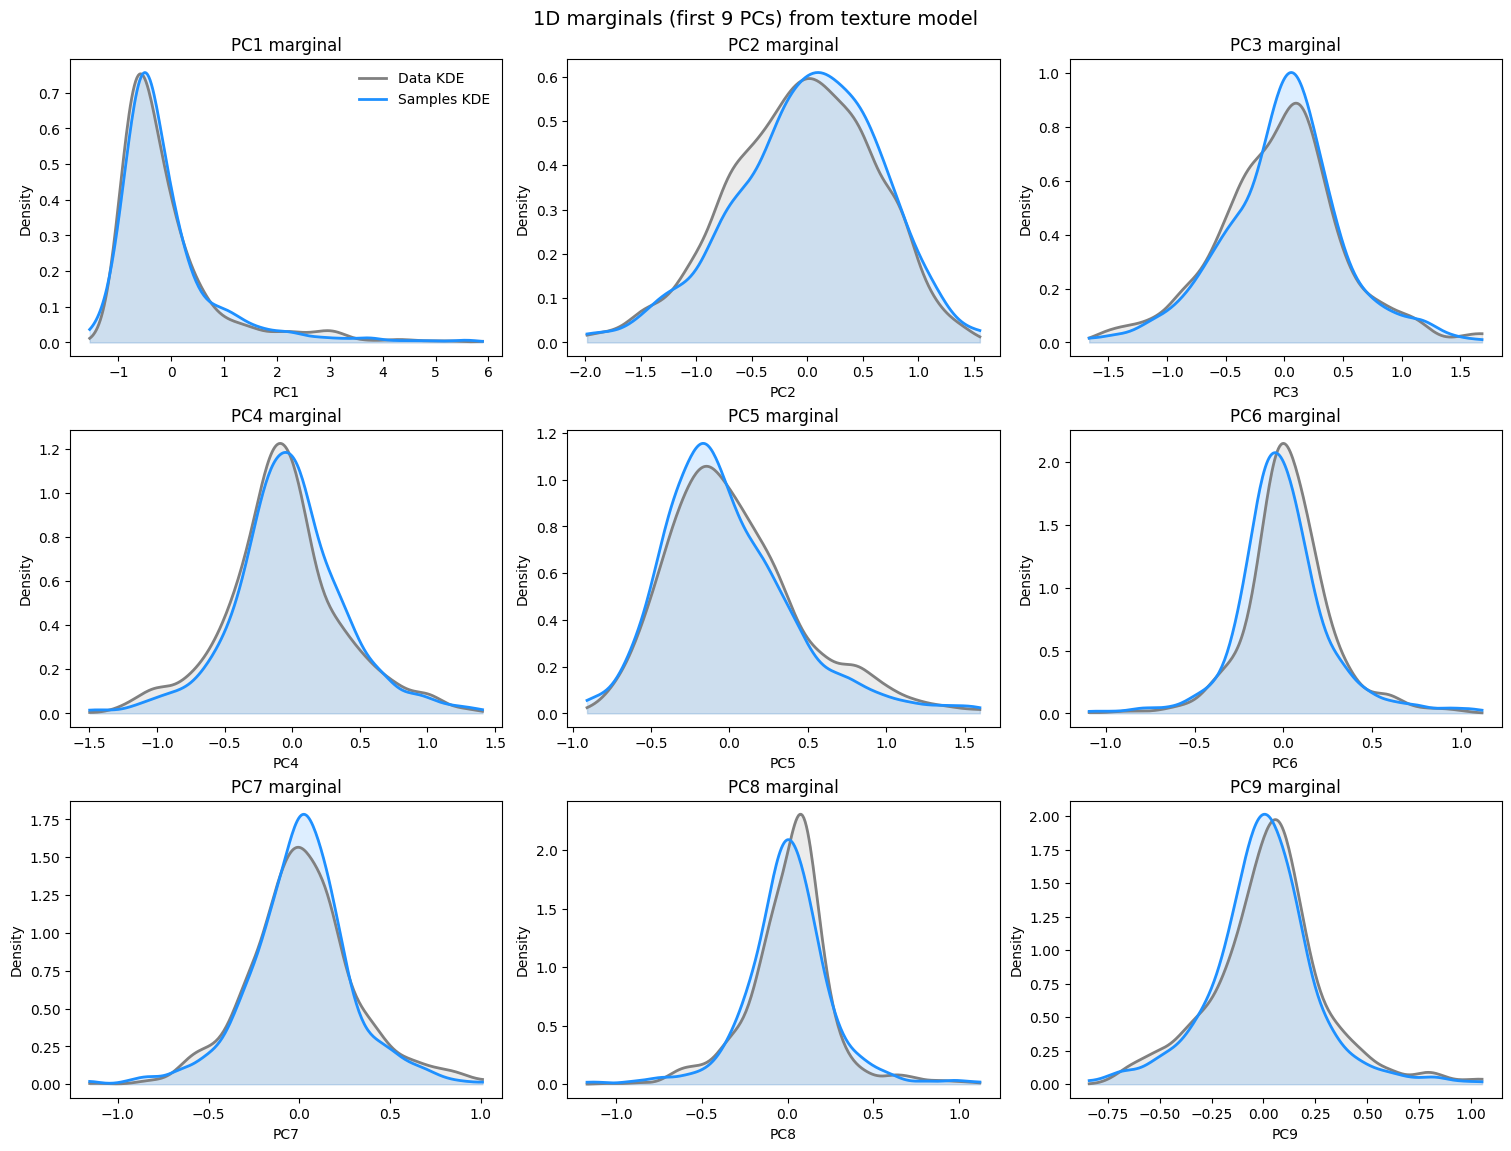

In [19]:
# x_numpy: (N, D) reference/data
# samples: (M, D) generated/sampled points
# columns are PCs

max_pcs = 9
bw_method = 0.2
grid_n = 300
seed = 0
sample_kde_subsample = 5000   # None for all points (can be slow if huge)

N, D = x_numpy.shape
M, D2 = samples.shape
assert D == D2, f"Dimension mismatch: x_numpy has {D}, samples has {D2}"
K = min(max_pcs, D)
assert K >= 1

rng = np.random.default_rng(seed)

# optional subsample for KDE speed on very large samples
if (sample_kde_subsample is not None) and (M > sample_kde_subsample):
    s_idx = rng.choice(M, size=sample_kde_subsample, replace=False)
    S_kde = samples[s_idx]
else:
    S_kde = samples

n_cols = min(3, K)
n_rows = int(np.ceil(K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.8*n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for pc in range(K):
    ax = axes[pc]
    x_ref = x_numpy[:, pc]
    x_sam = S_kde[:, pc]

    # robust plotting range from both sets
    lo, hi = np.percentile(np.concatenate([x_ref, x_sam]), [0.5, 99.5])
    xs = np.linspace(lo, hi, grid_n)

    kde_ref = gaussian_kde(x_ref, bw_method=bw_method)
    kde_sam = gaussian_kde(x_sam, bw_method=bw_method)

    y_ref = kde_ref(xs)
    y_sam = kde_sam(xs)

    ax.plot(xs, y_ref, color="gray", lw=2, label="Data KDE")
    ax.plot(xs, y_sam, color="dodgerblue", lw=2, label="Samples KDE")

    # optional light fill for readability
    ax.fill_between(xs, 0, y_ref, color="gray", alpha=0.15)
    ax.fill_between(xs, 0, y_sam, color="dodgerblue", alpha=0.15)

    ax.set_title(f"PC{pc+1} marginal")
    ax.set_xlabel(f"PC{pc+1}")
    ax.set_ylabel("Density")

# hide extra axes
for ax in axes[K:]:
    ax.set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle(f"1D marginals (first {K} PCs) from texture model", fontsize=14)
plt.show()

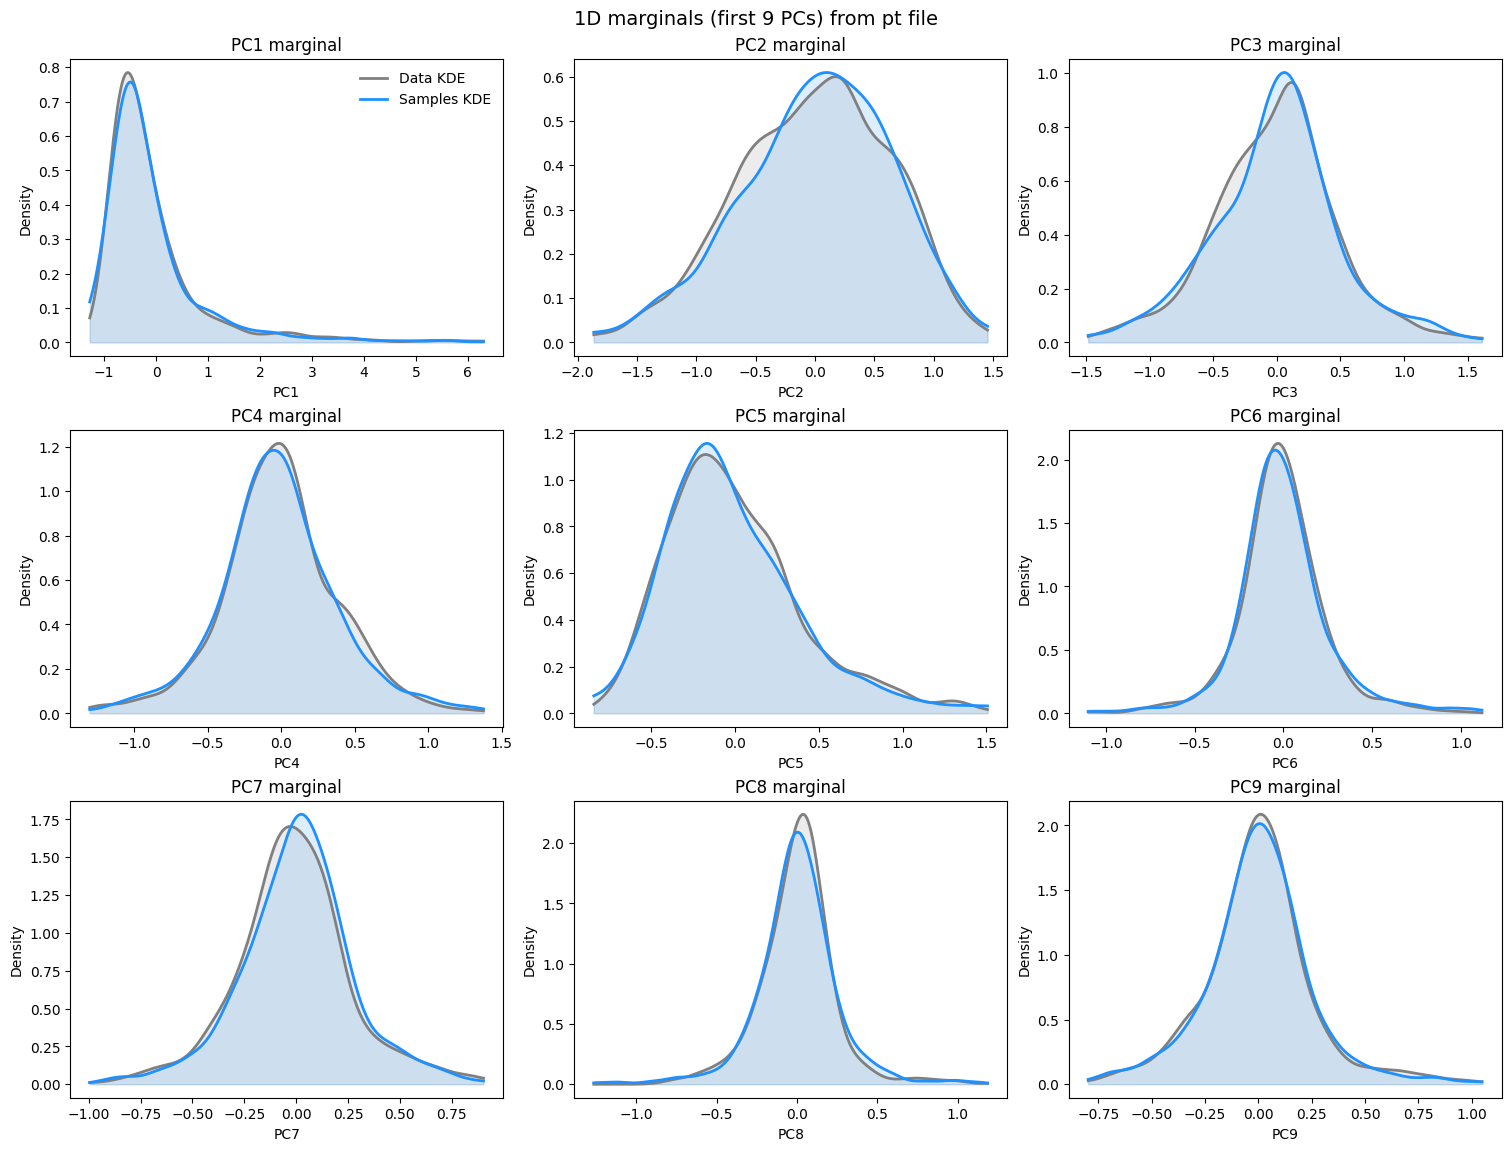

In [20]:
# x_numpy: (N, D) reference/data
# samples: (M, D) generated/sampled points
# columns are PCs

max_pcs = 9
bw_method = 0.2
grid_n = 300
seed = 0
sample_kde_subsample = 5000   # None for all points (can be slow if huge)

N, D = x_numpy.shape
M, D2 = samples.shape
assert D == D2, f"Dimension mismatch: x_numpy has {D}, samples has {D2}"
K = min(max_pcs, D)
assert K >= 1

rng = np.random.default_rng(seed)

# optional subsample for KDE speed on very large samples
if (sample_kde_subsample is not None) and (M > sample_kde_subsample):
    s_idx = rng.choice(M, size=sample_kde_subsample, replace=False)
    S_kde = samples[s_idx]
else:
    S_kde = samples

n_cols = min(3, K)
n_rows = int(np.ceil(K / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.8*n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for pc in range(K):
    ax = axes[pc]
    x_ref = pt_file[:sample_kde_subsample, pc]
    x_sam = S_kde[:, pc]

    # robust plotting range from both sets
    lo, hi = np.percentile(np.concatenate([x_ref, x_sam]), [0.5, 99.5])
    xs = np.linspace(lo, hi, grid_n)

    kde_ref = gaussian_kde(x_ref, bw_method=bw_method)
    kde_sam = gaussian_kde(x_sam, bw_method=bw_method)

    y_ref = kde_ref(xs)
    y_sam = kde_sam(xs)

    ax.plot(xs, y_ref, color="gray", lw=2, label="Data KDE")
    ax.plot(xs, y_sam, color="dodgerblue", lw=2, label="Samples KDE")

    # optional light fill for readability
    ax.fill_between(xs, 0, y_ref, color="gray", alpha=0.15)
    ax.fill_between(xs, 0, y_sam, color="dodgerblue", alpha=0.15)

    ax.set_title(f"PC{pc+1} marginal")
    ax.set_xlabel(f"PC{pc+1}")
    ax.set_ylabel("Density")

# hide extra axes
for ax in axes[K:]:
    ax.set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle(f"1D marginals (first {K} PCs) from pt file", fontsize=14)
plt.show()

In [ ]:
from itertools import combinations

# x_numpy shape: (N, D), columns are PCs
# e.g. x_numpy[:, 0] = PC1, x_numpy[:, 1] = PC2, etc.

max_pcs = 6                 # use first K PCs
points_per_panel = 2000     # scatter downsample for speed/readability (set None for all)
bw_method = 0.15            # KDE bandwidth
grid_n = 180                # KDE grid resolution
seed = 0

N, D = x_numpy.shape
K = min(max_pcs, D)
assert K >= 2, "Need at least 2 PCs"

pairs = list(combinations(range(K), 2))
n_pairs = len(pairs)

n_cols = min(3, n_pairs)
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

rng = np.random.default_rng(seed)
if (points_per_panel is not None) and (points_per_panel < N):
    idx = rng.choice(N, size=points_per_panel, replace=False)
    Xs = pt_file[idx]
else:
    Xs = pt_file

for ax, (i, j) in zip(axes, pairs):
    Z = pt_file[:2000, [i, j]]

    # robust bounds
    x_min, x_max = np.percentile(Z[:, 0], [0.5, 99.5])
    y_min, y_max = np.percentile(Z[:, 1], [0.5, 99.5])

    # KDE grid
    G0, G1 = np.meshgrid(np.linspace(x_min, x_max, grid_n),
                         np.linspace(y_min, y_max, grid_n))
    Q = gaussian_kde(Z.T, bw_method=bw_method)(
        np.vstack([G0.ravel(), G1.ravel()])
    ).reshape(G0.shape)

    # background density + contours
    ax.imshow(Q, origin="lower", extent=[x_min, x_max, y_min, y_max],
              cmap="YlOrRd", alpha=0.28, aspect="auto")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.45, alpha=0.3)

    # points
    ax.scatter(Xs[:, i], Xs[:, j], s=7, c="dodgerblue", alpha=0.22, linewidths=0)

    ax.set_title(f"PC{i+1} vs PC{j+1}")
    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel(f"PC{j+1}")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# hide unused subplot slots
for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle(f"All pairwise marginals among first {K} PCs", fontsize=14)
plt.show()

In [24]:
import os, tempfile
import numpy as np
import torch
from scipy.io import wavfile

sr_target = 41000

# ---------- helpers ----------
def rms_np(x):
    return np.sqrt(np.mean(np.square(x.astype(np.float64))))

def summarize(name, x):
    return {
        "name": name,
        "dtype": str(x.dtype),
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "rms": float(rms_np(x)),
    }

def to_float32_audio(x):
    """
    Convert scipy wavfile.read output to float32 in [-1, 1] convention when needed.
    """
    if x.dtype == np.int16:
        return (x.astype(np.float32) / 32768.0)
    elif x.dtype == np.int32:
        return (x.astype(np.float32) / 2147483648.0)
    elif np.issubdtype(x.dtype, np.floating):
        return x.astype(np.float32)
    else:
        raise ValueError(f"Unhandled dtype: {x.dtype}")

# ---------- choose one segment (already extracted in your notebook) ----------
# segment should be a 1D numpy array from your existing code
# sr_target should be same sample rate you currently write with (20000)
# Example assumptions:
# segment = audio[start_sample:end_sample]   # from your loop
# sr_target = 20000

seg = segment.astype(np.float64)  # original in-memory segment
tmp_dir = tempfile.mkdtemp(prefix="wav_dtype_compare_")
p_f32 = os.path.join(tmp_dir, "seg_f32.wav")
p_i16 = os.path.join(tmp_dir, "seg_i16.wav")

# write both
wavfile.write(p_f32, sr_target, seg.astype(np.float32))
wavfile.write(p_i16, sr_target, seg.astype(np.int16))

# read back both
sr_f32, x_f32_raw = wavfile.read(p_f32)
sr_i16, x_i16_raw = wavfile.read(p_i16)

# convert to common float convention for fair comparison
x_f32 = to_float32_audio(x_f32_raw)
x_i16 = to_float32_audio(x_i16_raw)

# if original segment scale is int-like, normalize for comparison too:
# orig = to_float32_audio(seg.astype(np.int16))  # optional, if seg is PCM-scale
orig = seg.astype(np.float32)

# align lengths (just in case)
n = min(len(orig), len(x_f32), len(x_i16))
orig, x_f32, x_i16 = orig[:n], x_f32[:n], x_i16[:n]

# error metrics
def err(a, b):
    d = (a - b).astype(np.float64)
    return {
        "mae": float(np.mean(np.abs(d))),
        "rmse": float(np.sqrt(np.mean(d**2))),
        "max_abs": float(np.max(np.abs(d))),
    }

print("Sample rates:", sr_f32, sr_i16)
print("\n--- signal summaries ---")
for row in [
    summarize("orig", orig),
    summarize("readback_float32", x_f32),
    summarize("readback_int16", x_i16),
]:
    print(row)

print("\n--- error vs orig ---")
print("float32_write:", err(orig, x_f32))
print("int16_write :", err(orig, x_i16))

print("\n--- direct float32 vs int16 readback ---")
print(err(x_f32, x_i16))


Sample rates: 41000 41000

--- signal summaries ---
{'name': 'orig', 'dtype': 'float32', 'min': -11801.0, 'max': 12363.0, 'mean': -0.006927083246409893, 'rms': 1580.4055704780076}
{'name': 'readback_float32', 'dtype': 'float32', 'min': -11801.0, 'max': 12363.0, 'mean': -0.006927083246409893, 'rms': 1580.4055704780076}
{'name': 'readback_int16', 'dtype': 'float32', 'min': -0.360137939453125, 'max': 0.377288818359375, 'mean': -2.1139780415069254e-07, 'rms': 0.04823015046624779}

--- error vs orig ---
float32_write: {'mae': 0.0, 'rmse': 0.0, 'max_abs': 0.0}
int16_write : {'mae': 1202.0299511842727, 'rmse': 1580.3573400956245, 'max_abs': 12362.623046875}

--- direct float32 vs int16 readback ---
{'mae': 1202.0299511842727, 'rmse': 1580.3573400956245, 'max_abs': 12362.623046875}
